In [1]:
# ============================================================
# KLASIFIKASI BENTUK WAJAH PRIA - INFERENCE
#
# Notebook mandiri untuk MEMAKAI model. Tidak butuh dataset,
# cukup folder artifacts/ hasil dari 14_train_final.ipynb.
#
# Parameter pra-pemrosesan dibaca dari model_config.json, bukan
# ditulis ulang di sini. Dengan begitu crop margin, ukuran gambar,
# dan urutan kelas dijamin sama persis dengan saat training.
# ============================================================

import os, glob, json, csv, time
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow import keras

try:
    import cv2
    HAS_CV2 = True
except ImportError:
    HAS_CV2 = False
    print("!! opencv belum ada: pip install opencv-python")
    print("   Tanpa itu face cropping dilewati dan akurasi turun ~5 poin.")

ART_DIR = "artifacts"        # folder hasil 14_train_final.ipynb
print("Siap.")

Siap.


In [2]:
# ---------- MUAT KONFIGURASI & MODEL (sekali saja) ----------
cfg_path = os.path.join(ART_DIR, "model_config.json")
if not os.path.exists(cfg_path):
    raise FileNotFoundError(
        f"{cfg_path} tidak ada. Jalankan 14_train_final.ipynb dulu, "
        f"atau ubah ART_DIR ke lokasi folder artifacts.")

CFG = json.load(open(cfg_path))
CLASSES     = CFG["classes"]
IMG_SIZE    = tuple(CFG["img_size"])
CROP_MARGIN = CFG["crop_margin"]
NUM_CLASSES = len(CLASSES)

model_paths = sorted(glob.glob(os.path.join(ART_DIR, "faceshape_fold*.keras")))
if not model_paths:
    raise FileNotFoundError(f"Tidak ada model .keras di {ART_DIR}/")

t0 = time.time()
MODELS = [keras.models.load_model(p) for p in model_paths]

if HAS_CV2:
    CASCADE = cv2.CascadeClassifier(cv2.data.haarcascades + CFG["cascade"])

print(f"Model dilatih : {CFG['dibuat']}")
print(f"Kelas         : {CLASSES}")
print(f"Ukuran input  : {IMG_SIZE} | crop margin {CROP_MARGIN}")
print(f"Ensemble      : {len(MODELS)} model ({time.time()-t0:.1f}s)")
print(f"\nPerforma pada data uji (out-of-fold, n={CFG['n_gambar']}):")
print(f"  akurasi top-1 : {CFG['oof_accuracy']*100:.2f}%")
print(f"  akurasi top-2 : {CFG['top2_accuracy']*100:.2f}%")
print(f"  tebak acak    : 25.00%")
print("  per kelas     :", {k: f"{v*100:.0f}%"
                            for k, v in CFG["akurasi_per_kelas"].items()})

2026-08-23 14:36:54.204601: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-08-23 14:36:54.204621: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-08-23 14:36:54.204624: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
I0000 00:00:1787470614.204635  493187 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1787470614.204649  493187 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model dilatih : 2026-08-23 14:36
Kelas         : ['ovale', 'rectangular', 'round', 'square']
Ukuran input  : (224, 224) | crop margin 0.35
Ensemble      : 5 model (3.3s)

Performa pada data uji (out-of-fold, n=1139):
  akurasi top-1 : 61.11%
  akurasi top-2 : 82.88%
  tebak acak    : 25.00%
  per kelas     : {'ovale': '51%', 'rectangular': '71%', 'round': '50%', 'square': '75%'}


In [3]:
# ---------- PRA-PEMROSESAN (identik dengan training) ----------
def crop_face(img_rgb):
    """Kembalikan (array uint8 seukuran IMG_SIZE, wajah_terdeteksi)."""
    if not HAS_CV2:
        im = Image.fromarray(img_rgb).resize(IMG_SIZE, Image.LANCZOS)
        return np.asarray(im, dtype=np.uint8), False

    h, w = img_rgb.shape[:2]
    faces = CASCADE.detectMultiScale(
        cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY), 1.1, 5, minSize=(60, 60))
    if len(faces):
        fx, fy, fw, fh = max(faces, key=lambda b: b[2]*b[3])
        mx, my = int(fw*CROP_MARGIN), int(fh*CROP_MARGIN)
        x1, y1 = max(0, fx-mx), max(0, fy-my)
        x2, y2 = min(w, fx+fw+mx), min(h, fy+fh+my)
        ok = True
    else:
        s = min(h, w); x1, y1 = (w-s)//2, (h-s)//2; x2, y2 = x1+s, y1+s
        ok = False
    crop = cv2.resize(img_rgb[y1:y2, x1:x2], IMG_SIZE,
                      interpolation=cv2.INTER_AREA)
    return crop.astype(np.uint8), ok


def load_rgb(path):
    with Image.open(path) as im:
        return np.asarray(im.convert("RGB"), dtype=np.uint8)


def predict_array(arr_uint8):
    """Rata-ratakan probabilitas dari seluruh model fold.
       Model menerima uint8 mentah; normalisasi ada di dalam model."""
    batch = arr_uint8[None]
    return np.mean([m.predict(batch, verbose=0)[0] for m in MODELS], axis=0)

print("Siap.")

Siap.


In [4]:
# ---------- PREDIKSI SATU GAMBAR ----------
def predict(path, show=True, verbose=True):
    rgb = load_rgb(path)
    crop, detected = crop_face(rgb)
    probs = predict_array(crop)

    order = np.argsort(probs)[::-1]
    t1, t2 = order[0], order[1]
    gap = probs[t1] - probs[t2]

    if verbose:
        print(os.path.basename(path))
        if not detected:
            print("  ! wajah tidak terdeteksi - dipakai center crop, "
                  "hasil kurang bisa dipercaya")
        print(f"  1. {CLASSES[t1]:<12} {probs[t1]*100:5.1f}%")
        print(f"  2. {CLASSES[t2]:<12} {probs[t2]*100:5.1f}%")
        if gap < 0.15:
            print(f"  -> selisih tipis ({gap*100:.1f} poin): baca sebagai "
                  f"'antara {CLASSES[t1]} dan {CLASSES[t2]}'")

    if show:
        fig, ax = plt.subplots(1, 3, figsize=(13, 4))
        ax[0].imshow(rgb); ax[0].axis("off"); ax[0].set_title("asli", fontsize=10)
        ax[1].imshow(crop); ax[1].axis("off")
        ax[1].set_title("yang dilihat model" +
                        ("" if detected else "\n(wajah tak terdeteksi)"),
                        fontsize=10)
        o = np.argsort(probs)
        cols = ["seagreen" if i == t1 else "lightsteelblue" for i in o]
        ax[2].barh([CLASSES[i] for i in o], [probs[i]*100 for i in o], color=cols)
        ax[2].set_xlim(0, 100); ax[2].set_xlabel("Probabilitas (%)")
        ax[2].set_title(f"{CLASSES[t1]} ({probs[t1]*100:.1f}%)", fontsize=11)
        plt.tight_layout(); plt.show()

    return {"file": os.path.basename(path), "prediksi": CLASSES[t1],
            "keyakinan": float(probs[t1]), "alternatif": CLASSES[t2],
            "keyakinan_alt": float(probs[t2]), "wajah_terdeteksi": detected,
            "probs": {CLASSES[i]: float(probs[i]) for i in range(NUM_CLASSES)}}

print("Fungsi predict() siap.")

Fungsi predict() siap.


2026-08-23 14:36:57.945825: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


round t5.jpg
  1. round         80.8%
  2. square        16.9%


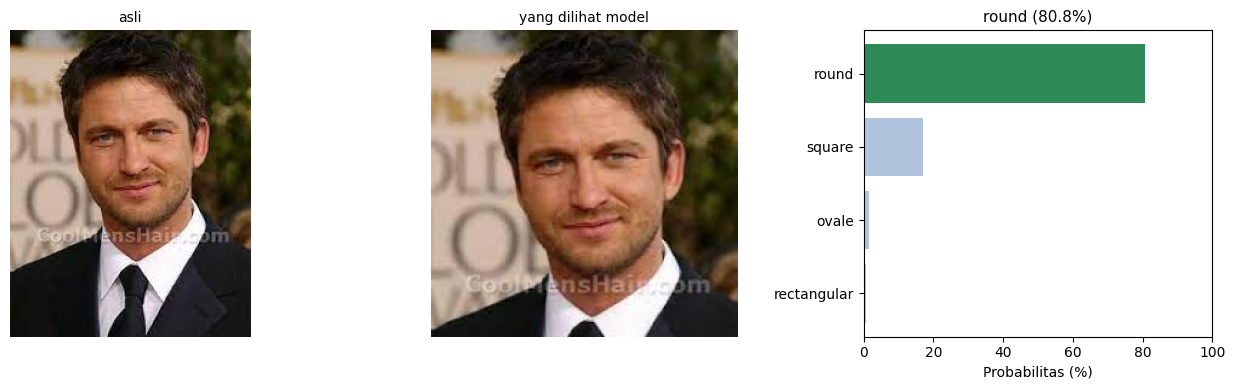

In [5]:
# ---------- CONTOH: SATU GAMBAR ----------
# Ganti dengan path fotomu sendiri.
CONTOH = "dataset/men/testing_set/round/round t5.jpg"

if os.path.exists(CONTOH):
    hasil = predict(CONTOH)
else:
    print("Ubah variabel CONTOH ke path gambar yang ada, lalu jalankan ulang.")
    print("Contoh:  predict('foto_saya.jpg')")

In [6]:
# ---------- BATCH: SATU FOLDER ----------
def predict_folder(folder, out_csv="hasil_prediksi.csv"):
    exts = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
    files = sorted(os.path.join(folder, f) for f in os.listdir(folder)
                   if f.lower().endswith(exts))
    if not files:
        print(f"Tidak ada gambar di {folder}"); return []

    rows, t0 = [], time.time()
    for i, p in enumerate(files, 1):
        try:
            rows.append(predict(p, show=False, verbose=False))
        except Exception as e:
            print(f"  gagal: {os.path.basename(p)} ({type(e).__name__})")
        if i % 25 == 0:
            print(f"  {i}/{len(files)}...")

    with open(out_csv, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["file", "prediksi", "keyakinan", "alternatif",
                    "keyakinan_alt", "wajah_terdeteksi"] + CLASSES)
        for r in rows:
            w.writerow([r["file"], r["prediksi"], f"{r['keyakinan']:.4f}",
                        r["alternatif"], f"{r['keyakinan_alt']:.4f}",
                        int(r["wajah_terdeteksi"])] +
                       [f"{r['probs'][c]:.4f}" for c in CLASSES])

    print(f"\n{len(rows)} gambar dalam {time.time()-t0:.1f}s -> {out_csv}")
    if rows:
        ct = Counter(r["prediksi"] for r in rows)
        conf = np.array([r["keyakinan"] for r in rows])
        nd = sum(1 for r in rows if not r["wajah_terdeteksi"])
        print("\nDistribusi prediksi:")
        for c in CLASSES:
            print(f"  {c:<14}: {ct.get(c, 0):>4}")
        print(f"Wajah tak terdeteksi : {nd} ({nd/len(rows)*100:.1f}%)")
        print(f"Keyakinan rata-rata  : {conf.mean()*100:.1f}%")
        print(f"Keyakinan < 50%      : {(conf < 0.5).sum()} (sebaiknya cek manual)")
    return rows

# Contoh:
# hasil = predict_folder("foto_saya/")
print("Fungsi predict_folder() siap.")

Fungsi predict_folder() siap.


In [7]:
# ---------- EVALUASI FOLDER BERLABEL (opsional) ----------
# Untuk folder berstruktur <root>/<kelas>/*.jpg
# PERINGATAN: kalau isinya gambar yang dipakai saat training, angkanya
# akan terlalu bagus dan tidak berarti. Pakai foto baru.
def evaluate_folder(root):
    from sklearn.metrics import classification_report, confusion_matrix
    import seaborn as sns

    y_true, y_pred, n_nd = [], [], 0
    for ci, c in enumerate(CLASSES):
        d = os.path.join(root, c)
        if not os.path.isdir(d):
            continue
        for fn in sorted(os.listdir(d)):
            if not fn.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                continue
            try:
                r = predict(os.path.join(d, fn), show=False, verbose=False)
            except Exception:
                continue
            y_true.append(ci); y_pred.append(CLASSES.index(r["prediksi"]))
            n_nd += (not r["wajah_terdeteksi"])

    if not y_true:
        print("Tidak ada gambar berlabel ditemukan."); return
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    print(f"n = {len(y_true)} | wajah tak terdeteksi: {n_nd}\n")
    print(classification_report(y_true, y_pred, target_names=CLASSES,
                                digits=4, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=range(NUM_CLASSES))
    plt.figure(figsize=(6.5, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES, cbar=False)
    plt.xlabel("Prediksi"); plt.ylabel("Label Sebenarnya")
    plt.title(f"Akurasi {(y_true==y_pred).mean()*100:.2f}%")
    plt.tight_layout(); plt.show()

# Contoh:
# evaluate_folder("foto_uji/")
print("Fungsi evaluate_folder() siap.")

Fungsi evaluate_folder() siap.


In [8]:
# ---------- PANDUAN MEMBACA HASIL ----------
oof = CFG["oof_accuracy"]*100
top2 = CFG["top2_accuracy"]*100
worst = min(CFG["akurasi_per_kelas"].items(), key=lambda kv: kv[1])
best  = max(CFG["akurasi_per_kelas"].items(), key=lambda kv: kv[1])

print(f"""
CARA MEMBACA HASIL
------------------
Model ini benar sekitar {oof:.0f}% dari waktu. Jawaban benar ada di dua
tebakan teratas sekitar {top2:.0f}% dari waktu. Karena itu output selalu
menampilkan dua tebakan, bukan satu.

  keyakinan > 70%               -> cukup bisa dipercaya
  keyakinan 40-70%              -> pertimbangkan juga tebakan kedua
  keyakinan < 40%               -> model tidak yakin, cek manual
  selisih dua teratas < 15 poin -> perlakukan sebagai dua kemungkinan

Kelas paling andal : {best[0]} ({best[1]*100:.0f}%)
Kelas paling sulit : {worst[0]} ({worst[1]*100:.0f}%)

Pasangan yang sering tertukar: square<->rectangular, round<->ovale.
Keduanya memang mirip secara visual, bahkan bagi manusia.

SYARAT FOTO YANG BAIK
---------------------
  - wajah menghadap depan, tidak miring jauh
  - pencahayaan merata, wajah tidak tertutup bayangan
  - rambut tidak menutupi dahi atau garis rahang
  - satu wajah per foto (kalau banyak, yang terbesar yang dipakai)

Kalau muncul "wajah tidak terdeteksi", model memakai center crop
dan hasilnya jauh kurang bisa dipercaya.

BATASAN
-------
Dilatih pada ~{CFG['n_gambar']} foto wajah pria dengan kualitas label
yang tidak sempurna. Tidak divalidasi untuk wajah perempuan, anak-anak,
atau kelompok etnis di luar yang ada di dataset. Jangan dipakai untuk
keputusan yang berdampak nyata bagi seseorang.
""")


CARA MEMBACA HASIL
------------------
Model ini benar sekitar 61% dari waktu. Jawaban benar ada di dua
tebakan teratas sekitar 83% dari waktu. Karena itu output selalu
menampilkan dua tebakan, bukan satu.

  keyakinan > 70%               -> cukup bisa dipercaya
  keyakinan 40-70%              -> pertimbangkan juga tebakan kedua
  keyakinan < 40%               -> model tidak yakin, cek manual
  selisih dua teratas < 15 poin -> perlakukan sebagai dua kemungkinan

Kelas paling andal : square (75%)
Kelas paling sulit : round (50%)

Pasangan yang sering tertukar: square<->rectangular, round<->ovale.
Keduanya memang mirip secara visual, bahkan bagi manusia.

SYARAT FOTO YANG BAIK
---------------------
  - wajah menghadap depan, tidak miring jauh
  - pencahayaan merata, wajah tidak tertutup bayangan
  - rambut tidak menutupi dahi atau garis rahang
  - satu wajah per foto (kalau banyak, yang terbesar yang dipakai)

Kalau muncul "wajah tidak terdeteksi", model memakai center crop
dan hasilnya 